In [15]:
import numpy as np
import matplotlib.pyplot as plt 

In [16]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [17]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    f_wb = np.dot(X, w) + b
    error = f_wb - y

    cost = (1 / (2 * m)) * np.sum(error ** 2)
    return cost

In [18]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]

    f_wb = np.dot(X, w) + b
    error = f_wb - y

    dj_dw = (1 / m) * np.dot(X.T, error)
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db

In [19]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    w = w_init.copy()
    b = b_init

    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        J_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i:4d}: Cost {cost:.4f}")
    return w, b, J_history

Iteration    0: Cost 115379623754.0179
Iteration  100: Cost 13241531101.0615
Iteration  200: Cost 1907167878.1156
Iteration  300: Cost 377113927.4138
Iteration  400: Cost 161499446.0646
Iteration  500: Cost 123435580.4267
Iteration  600: Cost 110348295.6842
Iteration  700: Cost 101590670.4880
Iteration  800: Cost 94230806.1073
Iteration  900: Cost 87741888.4730
Final w: [ 67076.75371573  56168.42604975  53461.48628656 -21932.94831829]
Final b: 445980.74562365457


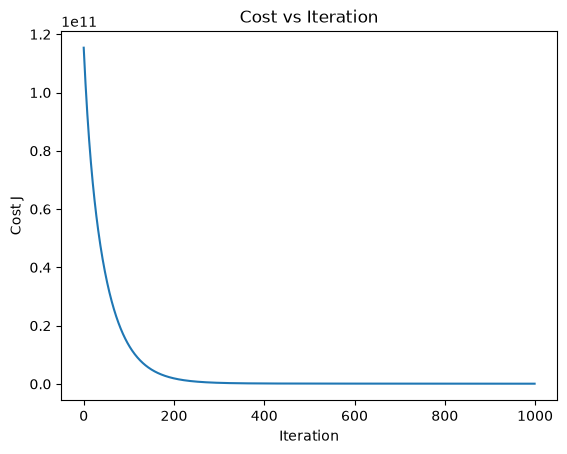

In [20]:
# Данные: площадь, комнаты, этажи, возраст
X_train = np.array([
    [120, 4, 2, 10],
    [80, 3, 1, 20],
    [150, 5, 2, 5],
    [60, 2, 1, 30],
    [200, 6, 3, 2]
])

y_train = np.array([440000, 280000, 560000, 200000, 750000])

# Scaling
X_norm, mu, sigma = zscore_normalize_features(X_train)

# Initial parameters
m, n = X_norm.shape
w_init = np.zeros(n)
b_init = 0

# Hyperparameters
alpha = 0.01
num_iters = 1000

# Train
w_final, b_final, J_history = gradient_descent(
    X_norm,
    y_train,
    w_init,
    b_init,
    alpha,
    num_iters
)

print("Final w:", w_final)
print("Final b:", b_final)

# Plot cost
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.title("Cost vs Iteration")
plt.show()

In [24]:
x_new = np.array([100, 3, 2, 15])

x_new_norm = (x_new - mu) / sigma

prediction = np.dot(x_new_norm, w_final) + b_final
print(prediction)

387609.788997943
